### Model Training Analysis

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set constants
REPO_ROOT = Path(os.getcwd()).resolve().parent
FIG_DIR = REPO_ROOT / "results" / "figures"# Load training data

In [2]:
# Load training data
results_df = pd.read_csv(REPO_ROOT / "results" / "metrics" / "brms_grid_search.csv")
results_df.head()

,model_name,prior_beta_sd,prior_int_mean,family,iter,warmup,train_time_min,mae,rmse,mape,coverage,waic,loo_ic
0,brms_beta0.5_int3.5_negbinomial_iter1000,0.5,3.5,negbinomial,1000,500,14.02,10.57,15.53,34.69,94.78,246341.21,246341.42
1,brms_beta1.0_int3.0_negbinomial_iter1000,1.0,3.0,negbinomial,1000,500,13.86,10.56,15.53,34.64,94.95,246339.08,246339.41
2,brms_beta1.0_int3.5_negbinomial_iter1000,1.0,3.5,negbinomial,1000,500,12.24,10.58,15.54,34.69,94.76,246340.48,246340.78
3,brms_beta1.0_int3.5_poisson_iter1000,1.0,3.5,poisson,1000,500,16.13,10.61,15.61,34.74,70.33,329063.27,329064.58


In [3]:
# Map the model names to human readable names
map = {
    "brms_beta0.5_int3.5_negbinomial_iter1000": "Beta(0.5, 3.5) NB",
    "brms_beta1.0_int3.0_negbinomial_iter1000": "Beta(1.0, 3.0) NB",
    "brms_beta1.0_int3.5_negbinomial_iter1000": "Beta(1.0, 3.5) NB",
    "brms_beta1.0_int3.5_poisson_iter1000": "Beta(1.0, 3.5) POIS",
}

results_df["model_name_hf"] = results_df["model_name"].map(map)

/var/folders/v9/sbw6dcrd0y1_4_5_6zn5lw6h0000gn/T/ipykernel_42225/1072199267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


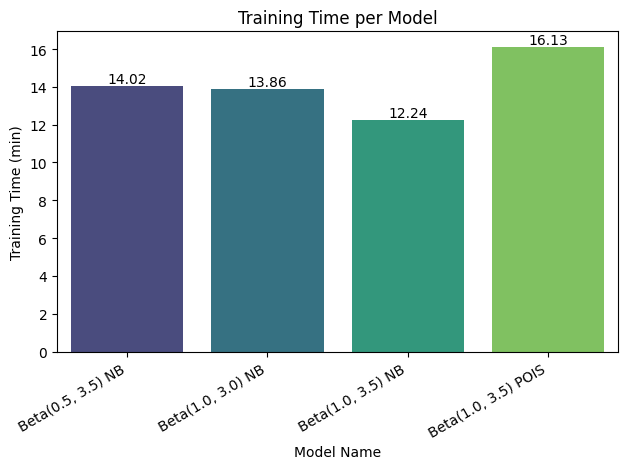

In [4]:
# Training time per model
ax = sns.barplot(
    data=results_df,
    x="model_name_hf",
    y="train_time_min",
    palette="viridis"
)
ax.set_ylabel("Training Time (min)")
ax.set_xlabel("Model Name")
ax.set_title("Training Time per Model")
plt.xticks(rotation=30, ha='right')

# Show exact value on top of each bar
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# Save plot
plt.savefig(FIG_DIR / "training_time_per_model.png", dpi=300)

plt.show()

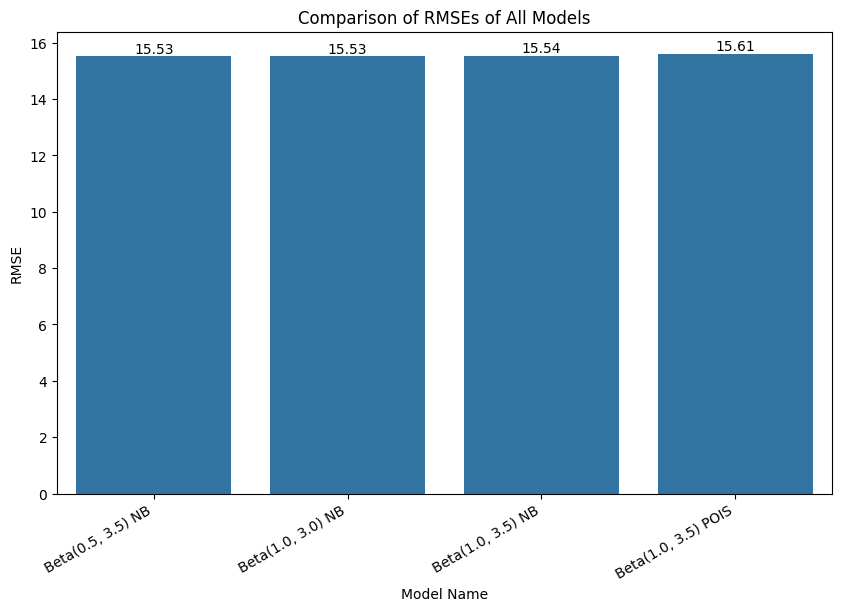

In [5]:
# RMSE over all models
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="model_name_hf", y="rmse", data=results_df)
plt.xticks(rotation=30, ha='right')
plt.xlabel("Model Name")
plt.ylabel("RMSE")
plt.title("Comparison of RMSEs of All Models")

# Add exact values above each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=10)

# Save plot
plt.savefig(FIG_DIR / "rmse_over_all_models.png", dpi=300)

plt.show()

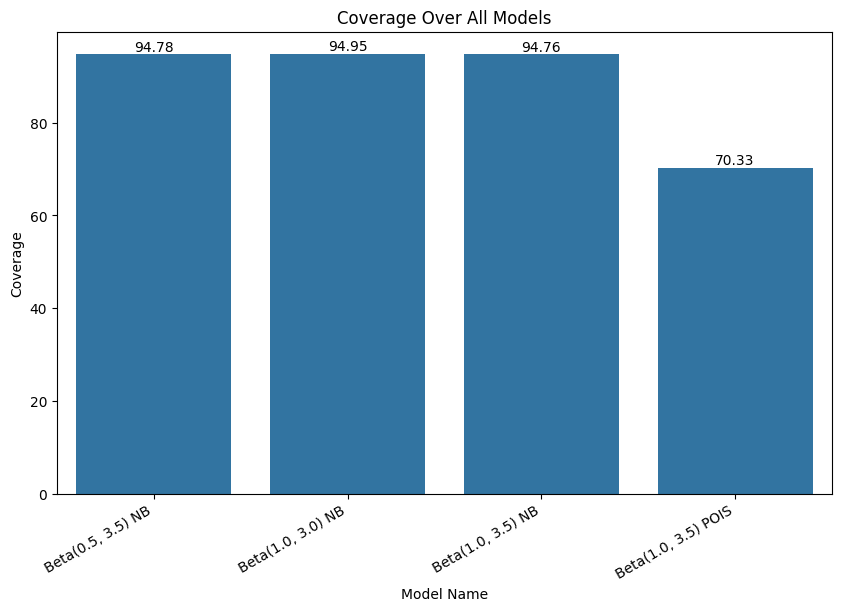

In [6]:
# Coverage over all models
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="model_name_hf", y="coverage", data=results_df)
plt.xticks(rotation=30, ha='right')
plt.xlabel("Model Name")
plt.ylabel("Coverage")
plt.title("Coverage Over All Models")

# Add exact values above each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=10)

# Save plot
plt.savefig(FIG_DIR / "coverage_over_all_models.png", dpi=300)

plt.show()


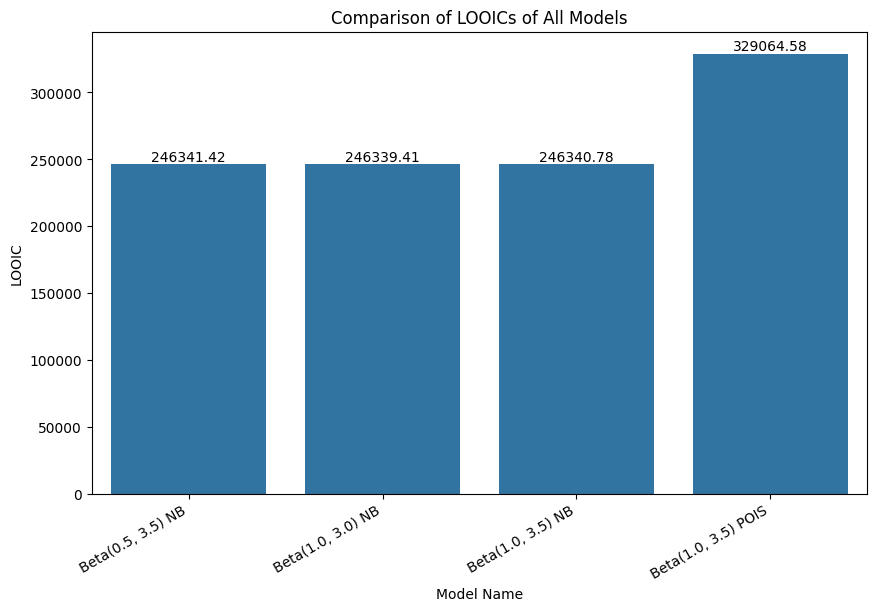

In [8]:
# LOO information criterion for all models
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="model_name_hf", y="loo_ic", data=results_df)
plt.xticks(rotation=30, ha='right')
plt.xlabel("Model Name")
plt.ylabel("LOOIC")
plt.title("Comparison of LOOICs of All Models")

# Add exact values above each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=10)

# Save plot
plt.savefig(FIG_DIR / "looic_over_all_models.png", dpi=300)

plt.show()


**Analysis**
1. All of the Negative Binomial models performed similarly, with the Poission baseline BRMS model performing significantly worse across all performance metrics (except for RMSE)
2. When comparing between the Bayesian Negative Bernoulli models using the LOO IC, all of the models performed +/- 1, which is expected with a large amount of data that we used (~37K records)
3. Coverage wise, all of the models performed very similar to eachother.

This likely means that we need to add more features to the model to help account for things that may not already be in the data.